# Project 2: Exploratory Data Analysis (EDA) Report
---
## Assigned Topic:
__[Wind Turbine]__

## Selected Problem Statement: 
__[Approach: Renewable Energy Private Equity Investment
Problem Statement: A private equity firm focused on renewable energy aims to acquire U.S. wind farms but requires deeper insight into the specific structural characteristics and geographic locations that drive peak energy efficiency. To guide these acquisitions, the Investment Committee must evaluate historical Net Generation (MWh) data across various Census Regions, segmented by turbine specifications and technical details. By spotting niche opportunities, distinguishing the physical configurations and regions with the strongest historical performance, the firm can strategically target assets that meet proven benchmarks for high energy output.]__

## 1. Introduction & Objectives
*(Guidelines: Introduce your topic and give a brief high-level overview of the industry or topic you are exploring so a non-technical audience understands the context.)*

### 1.1 Context & Background

### 1.2 Core Analytical Objectives
*(List the key targeted questions that will guide your analysis to solve the chosen problem statement. Use bullet points.)*
* ...
* ...

---

## 2. Environment Setup & Data Collection
*(Rubric Checkpoint: Ensure all modules are imported cleanly with appropriate standard aliases. Data files must be loaded using relative paths for replicability.)*

In [117]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import datetime
import missingno as msno


In [147]:
# Load data using strictly relative file paths
wind_turbines = pd.read_csv('wind-turbines.csv' , encoding='latin-1')
avg_bills = pd.read_csv('./extra/average_electricity_bills.csv')
avg_rates=pd.read_csv('./extra/average_electricity_rates.csv')
windiest_states=pd.read_csv('./extra/windiest-states-in-the-us.-2025.csv')

wind_clean = wind_turbines.copy()

---
## 3. Data Handling


In [148]:
# check the dataset 
# wind_turbines[].head()
display(wind_turbines[wind_turbines['t_manu'].str.lower().str.contains('siemens')]['t_manu'].value_counts())
display(wind_turbines[wind_turbines['t_manu'].str.lower().str.contains('gamesa')]['t_manu'].value_counts())


t_manu
Siemens                            5035
Siemens Gamesa Renewable Energy    2043
Name: count, dtype: int64

t_manu
Gamesa                             3077
Siemens Gamesa Renewable Energy    2043
Name: count, dtype: int64

In [149]:
# Check info
wind_turbines.info()

<class 'pandas.DataFrame'>
RangeIndex: 70808 entries, 0 to 70807
Data columns (total 27 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   case_id        70808 non-null  int64  
 1   faa_ors        65016 non-null  str    
 2   faa_asn        65686 non-null  str    
 3   usgs_pr_id     38263 non-null  float64
 4   eia_id         65015 non-null  float64
 5   t_state        70808 non-null  str    
 6   t_county       70808 non-null  str    
 7   t_fips         70808 non-null  int64  
 8   p_name         70808 non-null  str    
 9   p_year         70195 non-null  float64
 10  p_tnum         70808 non-null  int64  
 11  p_cap          66326 non-null  float64
 12  t_manu         65168 non-null  str    
 13  t_model        65031 non-null  str    
 14  t_cap          65328 non-null  float64
 15  t_hh           64628 non-null  float64
 16  t_rd           64874 non-null  float64
 17  t_rsa          64874 non-null  float64
 18  t_ttlh         64

In [150]:
#null values
wind_clean.isnull().sum().sort_values(ascending=False)


retrofit_year    64822
usgs_pr_id       32545
t_img_date        8316
t_hh              6180
t_ttlh            6180
t_rd              5934
t_rsa             5934
eia_id            5793
faa_ors           5792
t_model           5777
t_manu            5640
t_cap             5480
faa_asn           5122
p_cap             4482
p_year             613
t_state              0
case_id              0
t_fips               0
t_county             0
p_tnum               0
p_name               0
t_conf_atr           0
retrofit             0
t_conf_loc           0
t_img_srce           0
xlong                0
ylat                 0
dtype: int64

In [151]:
# summary data types
wind_clean.dtypes

case_id            int64
faa_ors              str
faa_asn              str
usgs_pr_id       float64
eia_id           float64
t_state              str
t_county             str
t_fips             int64
p_name               str
p_year           float64
p_tnum             int64
p_cap            float64
t_manu               str
t_model              str
t_cap            float64
t_hh             float64
t_rd             float64
t_rsa            float64
t_ttlh           float64
retrofit           int64
retrofit_year    float64
t_conf_atr         int64
t_conf_loc         int64
t_img_date           str
t_img_srce           str
xlong            float64
ylat             float64
dtype: object

In [152]:
wind_clean.describe()

,case_id,usgs_pr_id,eia_id,t_fips,p_year,p_tnum,p_cap,t_cap,t_hh,t_rd,t_rsa,t_ttlh,retrofit,retrofit_year,t_conf_atr,t_conf_loc,xlong,ylat
count,7.080800e+04,38263.000000,65015.000000,70808.000000,70195.000000,70808.000000,66326.000000,65328.000000,64628.000000,64874.000000,64874.000000,64628.000000,70808.000000,5986.000000,70808.000000,70808.000000,70808.000000,70808.000000
mean,3.058490e+06,27523.587225,57877.751642,32244.494097,2011.650659,104.360552,170.176128,1963.534151,81.054571,95.663717,7618.500657,129.050593,0.084538,2018.640327,2.766509,2.883784,-100.086457,38.479503
std,3.242377e+04,13564.446593,5984.516487,15498.246596,7.879099,93.954786,104.478693,717.067912,12.028726,23.424346,3309.229282,22.185981,0.278196,1.112294,0.597195,0.462326,11.141025,5.429730
min,3.000001e+06,1.000000,90.000000,2013.000000,1981.000000,1.000000,0.050000,50.000000,19.000000,13.400000,141.030000,30.400000,0.000000,2015.000000,1.000000,1.000000,-171.713074,13.389381
25%,3.032230e+06,18625.500000,56763.000000,19081.000000,2008.000000,56.000000,99.000000,1500.000000,80.000000,82.000000,5281.020000,121.000000,0.000000,2018.000000,3.000000,3.000000,-103.037155,34.428043
50%,3.050978e+06,28598.000000,57752.000000,35057.000000,2012.000000,85.000000,158.000000,2000.000000,80.000000,100.000000,7853.980000,130.100000,0.000000,2019.000000,3.000000,3.000000,-99.393761,39.052442
75%,3.090448e+06,38719.500000,60338.000000,48141.000000,2018.000000,121.000000,211.220000,2300.000000,87.000000,110.000000,9503.320000,145.100000,0.000000,2020.000000,3.000000,3.000000,-95.202499,42.812810
max,3.118671e+06,49135.000000,65270.000000,72133.000000,2021.000000,731.000000,525.020000,6000.000000,131.000000,155.000000,18869.190000,199.600000,1.000000,2020.000000,3.000000,3.000000,144.722656,66.839905


---
## 4. Exploratory Data Analysis (EDA)
*(Rubric Checkpoint: Demonstrate mastery of basic descriptive statistics, sorting records, and applying Boolean masking techniques to isolate specific baseline metrics.)*

### 4.1. ----

In [153]:
# Compute appropriate summary statistics
def assign_region(state):
    if state in ['ME', 'NH', 'VT', 'MA', 'RI', 'CT', 'NY', 'PA', 'NJ']:
        return 'Northeast'
    elif state in ['IL', 'IN', 'MI', 'OH', 'WI', 'IA', 'KS', 'MN', 'MO', 'NE', 'ND', 'SD']:
        return 'Midwest'
    elif state in ['DE', 'FL', 'GA', 'MD', 'NC', 'SC', 'VA', 'WV', 'AL', 'KY', 'MS', 'TN', 'AR', 'LA', 'OK', 'TX', 'DC']:
        return 'South'
    elif state in ['AZ', 'CO', 'ID', 'MT', 'NV', 'NM', 'UT', 'WY', 'AK', 'CA', 'HI', 'OR', 'WA']:
        return 'West'
    else:
        return 'Unknown'

wind_clean['census_region'] = wind_clean['t_state'].apply(assign_region)
wind_clean = wind_clean[wind_clean['census_region'] != 'Unknown']
wind_clean = wind_clean.dropna(subset=['census_region', 'p_cap'])
wind_clean['Net_Generation_(MWh)']=wind_clean['t_cap']/1000

wind_clean

,case_id,faa_ors,faa_asn,usgs_pr_id,eia_id,t_state,t_county,t_fips,p_name,p_year,...,retrofit,retrofit_year,t_conf_atr,t_conf_loc,t_img_date,t_img_srce,xlong,ylat,census_region,Net_Generation_(MWh)
0,3072661,NaN,NaN,5149.0,52161.0,CA,Kern County,6029,251 Wind,1987.0,...,0,NaN,2,3,5/8/2018,Digital Globe,-118.363762,35.077908,West,0.095
1,3072695,NaN,NaN,5143.0,52161.0,CA,Kern County,6029,251 Wind,1987.0,...,0,NaN,2,3,5/8/2018,Digital Globe,-118.364410,35.077435,West,0.095
2,3072704,NaN,NaN,5146.0,52161.0,CA,Kern County,6029,251 Wind,1987.0,...,0,NaN,2,3,5/8/2018,Digital Globe,-118.364197,35.077644,West,0.095
3,3063272,19-028134,2014-WTE-4084-OE,NaN,NaN,IA,Story County,19169,30 MW Iowa DG Portfolio,2017.0,...,0,NaN,3,3,4/24/2017,Digital Globe,-93.430367,42.028233,Midwest,3.000
4,3053390,19-028015,2015-WTE-6386-OE,NaN,NaN,IA,Boone County,19015,30 MW Iowa DG Portfolio,2017.0,...,0,NaN,3,3,6/1/2017,Digital Globe,-93.700424,41.977608,Midwest,3.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69938,3000251,NaN,NaN,3028.0,NaN,CA,Kern County,6029,unknown Tehachapi Wind Resource Area 3,2005.0,...,0,NaN,1,3,1/1/2012,NAIP,-118.308891,35.050797,West,NaN
69939,3002785,NaN,NaN,3868.0,NaN,CA,Kern County,6029,unknown Tehachapi Wind Resource Area 3,2005.0,...,0,NaN,1,3,1/1/2012,NAIP,-118.290489,35.050896,West,NaN
69940,3001812,NaN,NaN,3084.0,NaN,CA,Kern County,6029,unknown Tehachapi Wind Resource Area 3,2005.0,...,0,NaN,1,3,11/3/2018,Digital Globe,-118.301392,35.051697,West,NaN
69941,3009622,NaN,NaN,3048.0,NaN,CA,Kern County,6029,unknown Tehachapi Wind Resource Area 3,2005.0,...,0,NaN,1,3,11/3/2018,Digital Globe,-118.309685,35.045795,West,NaN


In [154]:
us_state_abbrev = {
    'Alabama':'AL','Alaska':'AK','Arizona':'AZ','Arkansas':'AR','California':'CA','Colorado':'CO',
    'Connecticut':'CT','Delaware':'DE','Florida':'FL','Georgia':'GA','Hawaii':'HI','Idaho':'ID',
    'Illinois':'IL','Indiana':'IN','Iowa':'IA','Kansas':'KS','Kentucky':'KY','Louisiana':'LA',
    'Maine':'ME','Maryland':'MD','Massachusetts':'MA','Michigan':'MI','Minnesota':'MN','Mississippi':'MS',
    'Missouri':'MO','Montana':'MT','Nebraska':'NE','Nevada':'NV','New Hampshire':'NH','New Jersey':'NJ',
    'New Mexico':'NM','New York':'NY','North Carolina':'NC','North Dakota':'ND','Ohio':'OH','Oklahoma':'OK',
    'Oregon':'OR','Pennsylvania':'PA','Rhode Island':'RI','South Carolina':'SC','South Dakota':'SD',
    'Tennessee':'TN','Texas':'TX','Utah':'UT','Vermont':'VT','Virginia':'VA','Washington':'WA',
    'West Virginia':'WV','Wisconsin':'WI','Wyoming':'WY','District of Columbia':'DC'}
windiest_states['state'] = windiest_states['state'].str.strip().str.title().map(us_state_abbrev)
avg_bills['State']=avg_bills['State'].str.strip().str.title().map(us_state_abbrev)
avg_rates['State']=avg_rates['State'].str.strip().str.title().map(us_state_abbrev)


In [155]:
windiest_states.drop(columns='stateFlagCode')


,state,WindiestStatesAverageWindSpeedMPH,MeanWindSpeed328ft,MeanWindPower328ft,MeanWindSpeed33ft
0,SD,21.32,20.3,722,12.8
1,MT,21.03,20.5,985,13.5
2,WY,20.88,21.5,964,14.1
3,ID,20.59,16.5,472,10.6
4,CO,20.16,20.0,751,12.8
5,MD,19.74,17.7,556,11.4
6,VA,19.32,17.2,567,10.3
7,MO,19.31,18.8,541,11.3
8,KS,19.30,19.9,657,12.3
9,ND,18.80,19.6,660,12.3


In [156]:
manufactor = {'Siemens Gamesa Renewable Energy':'Siemens','Gamesa':'Siemens'}

wind_clean['t_manu']=wind_clean['t_manu'].replace(manufactor)

In [158]:
wind_clean['t_manu']

0        Vestas
1        Vestas
2        Vestas
3        Nordex
4        Nordex
          ...  
69938       NaN
69939       NaN
69940       NaN
69941       NaN
69942       NaN
Name: t_manu, Length: 66263, dtype: str

In [ ]:
# wind_merge = pd.merge(right=wind_clean, left=windiest_states, on='state', how='left')

### 4.2. ----

In [ ]:
# Target Analysis Block 1:


### 4.3. ----

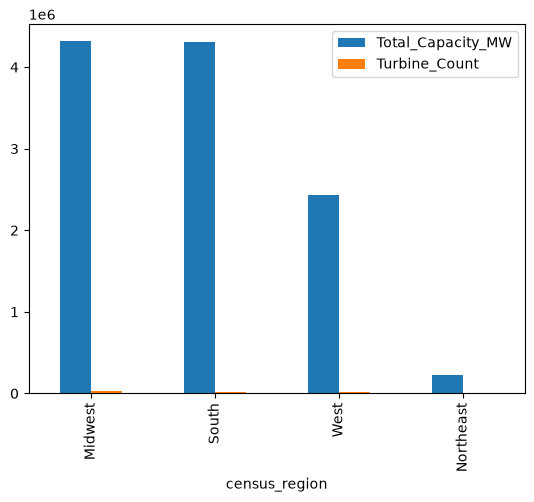

In [38]:
# Visualization 1 
regions = wind_clean.groupby('census_region')['t_cap']
)
regions = regions.sort_values(by='Total_Capacity_MW', ascending=False)
regions.plot(kind='bar');

**Visualization 1 Interpretation:**
> *Write 2-3 sentences explaining exactly what relationship or pattern this chart demonstrates and how it addresses your project objectives.*

In [ ]:
# Visualization 2

**Visualization 2 Interpretation:**
> *Write 2-3 sentences explaining exactly what relationship or pattern this chart demonstrates and how it addresses your project objectives.*

---
## 5. Summary of Findings & Actionable Recommendations
*(Guidelines: Connect individual observations into a cohesive narrative that guides the target non-technical audience toward data-driven actions.)*

### 5.1 Key Insights (Summary of Findings)
*(Use bullet points to highlight the core truths revealed by your analysis)*
* ...
* ...

### 5.2 Actionable Recommendations
*(Translate your data into clear choices or recommendations for your stakeholder based directly on the problem statement)*
* ...
* ...

### 5.3 Limitations & Areas for Further Research
* ...

---

## 6. Data Dictionary & References

### 6.1 Data Dictionary
| Feature / Column | Data Type | Source | Description |
|:---|:---|:---|:---|
| column_name_1 | type | Original / Engineered | Detailed explanation of what this variable represents |
| column_name_2 | type | Original / Engineered | Detailed explanation of what this variable represents |

### 6.2 References & Sources
* *Source 1:*